Load data and model

In [1]:
import pandas as pd
import pickle
import sys
sys.path.append("..")


df = pd.read_pickle("../data/features_v2.pkl")
with open("../models/model_v2.pkl", "rb") as f:
    model = pickle.load(f)

Prepare the data

In [2]:
from python_editor.data_processing import split_by_developer

train, test = split_by_developer(df, test_size=0.3, random_state=0)

In [5]:
from python_editor.feature_generation_v2 import get_vectorized_features_and_label, TRANSFORMED_FEATURES, LOG_FEATURES

X_test, y_test = get_vectorized_features_and_label(test, TRANSFORMED_FEATURES)

Get predictions

In [6]:
y_pred = model.predict(X_test)

We slightly improved the asymmetry in residuals (now range from -6 to 6)

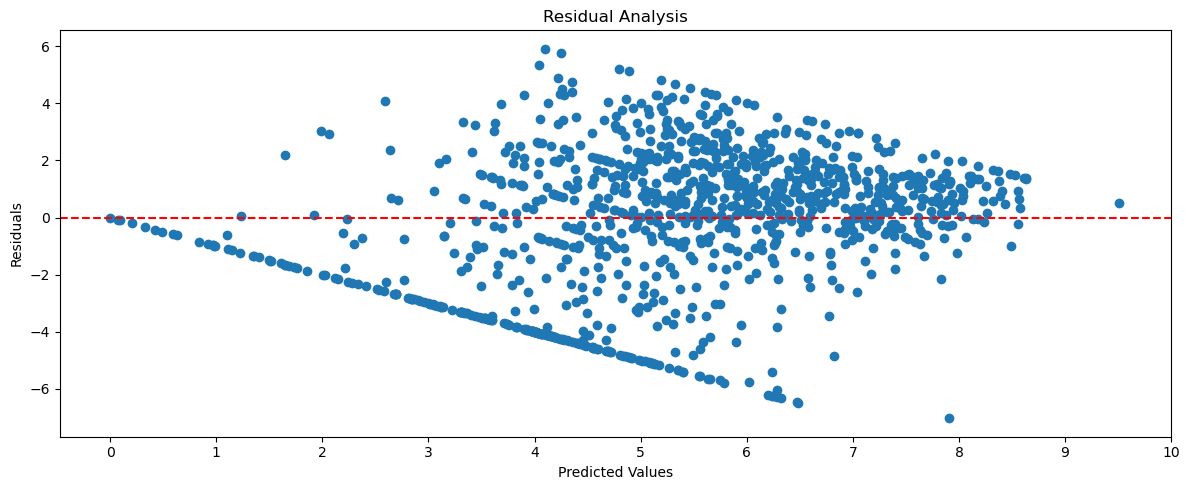

In [16]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

plt.scatter(y_pred, y_test-y_pred)
plt.axhline(y=0, color="r", linestyle="--")
plt.xticks(range(11))
plt.title("Residual Analysis")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [17]:
test.loc[:, "error"] = y_test - y_pred

/tmp/ipykernel_3917/4180407341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, "error"] = y_test - y_pred


We examine top performing, most over estimated and most under estimated examples

In [21]:
import numpy as np
from python_editor.model_evaluation import get_top_k

test_og = test.copy()
test_og.loc[:, LOG_FEATURES] = np.expm1(test_og[LOG_FEATURES])

top_performing, most_over_estimated, most_under_estimated = get_top_k(test_og, "error", 3)

to_display = TRANSFORMED_FEATURES + ["pylint_score", "error"]
pd.set_option("display.max_columns", None)

Top performing examples have:

1- Average to low number of characters

2- No docstring

In [24]:
top_performing[to_display]

,characters,code_compactness,line_length_std,long_line,trailing_ws,bad_name,bare_except,comment_ratio,has_docstring,variable_density,func_density,avg_func_lines,avg_func_args,too_many_args,class_density,avg_class_lines,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
3241,7865.0,0.925234,46.631282,1.0,0.0,0.0,0.0,0.030303,0.0,0.020202,0.020202,4.0,2.000000,0.0,0.010101,100.00,2.0,0.000000,1.0,0.00000,0.000000
1802,462.0,0.736842,17.169771,0.0,0.0,0.0,0.0,0.000000,0.0,0.071429,0.000000,0.0,0.000000,0.0,0.000000,0.00,0.0,0.000000,0.0,5.00000,0.001382
558,2823.0,0.734694,22.121294,0.0,0.0,0.0,0.0,0.000000,0.0,0.041667,0.125000,5.0,0.888889,0.0,0.055556,12.75,1.5,0.230769,0.0,5.47619,0.007026


Overestimated examples have:

1- Average to high number of characters

2- Functions/Classes

In [26]:
most_over_estimated[to_display]

,characters,code_compactness,line_length_std,long_line,trailing_ws,bad_name,bare_except,comment_ratio,has_docstring,variable_density,func_density,avg_func_lines,avg_func_args,too_many_args,class_density,avg_class_lines,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
1982,5072.0,0.838235,21.980027,0.0,0.0,0.0,0.0,0.114035,1.0,0.043860,0.070175,11.125000,2.750000,0.0,0.017544,52.5,4.0,0.8,0.0,0.877193,-7.026585
448,13122.0,0.898693,18.761256,0.0,0.0,1.0,0.0,0.083636,0.0,0.120000,0.069091,13.578947,1.315789,0.0,0.003636,278.0,19.0,0.0,1.0,0.000000,-6.478652
212,7269.0,0.854962,18.189882,0.0,0.0,0.0,0.0,0.160714,0.0,0.022321,0.066964,16.000000,1.266667,0.0,0.000000,0.0,0.0,0.0,1.0,0.000000,-6.470109


Underestimated examples have: 

1- Low number of characters

2- No functions/classes

In [28]:
most_under_estimated[to_display]

,characters,code_compactness,line_length_std,long_line,trailing_ws,bad_name,bare_except,comment_ratio,has_docstring,variable_density,func_density,avg_func_lines,avg_func_args,too_many_args,class_density,avg_class_lines,avg_class_methods,func_class_docstring_ratio,unused_imports,pylint_score,error
1649,1185.0,0.944444,21.354805,0.0,0.0,1.0,0.0,0.019608,1.0,0.019608,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.000,5.905738
2470,212.0,0.714286,11.754148,0.0,0.0,0.0,0.0,0.100000,1.0,0.400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.000,5.749806
364,1298.0,1.000000,15.886172,0.0,0.0,0.0,0.0,0.032258,0.0,0.032258,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.375,5.337577


Feature importance shows that the model relies on our new features

In [34]:
from python_editor.model_evaluation import get_feature_importance


embedding_dim = test["embedding"][0].shape[0]

importance_df = get_feature_importance(model, embedding_dim, TRANSFORMED_FEATURES)
importance_df.head(10)

,feature,importance
449,449,0.055733
770,line_length_std,0.034845
137,137,0.017902
782,class_density,0.017655
772,trailing_ws,0.017297
672,672,0.013201
66,66,0.012958
777,variable_density,0.012629
318,318,0.012092
561,561,0.009390


In [35]:
X_train, y_train = get_vectorized_features_and_label(train, TRANSFORMED_FEATURES)

Shapley values confirms that new features are relevant

 99%|===================| 1053/1060 [00:58<00:00]        

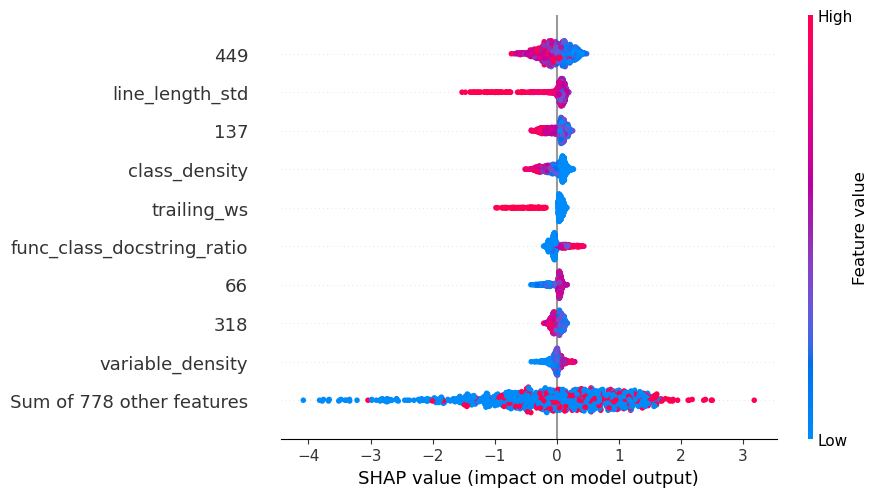

In [37]:
import shap
from python_editor.model_evaluation import get_shap_df
shap.initjs()

shap_values = get_shap_df(model, embedding_dim, TRANSFORMED_FEATURES, X_train, X_test)
shap.plots.beeswarm(shap_values)

We compare our model with pylint in terms of latency. Pylint is 3x faster than our model likely due to time used to generate embeddings. We will try to train a model on our generated features only.

In [4]:
from python_editor.model_v2 import get_model_prediction_from_text
from python_editor.data_processing import get_pylint_text
from python_editor.model_evaluation import compare_time

compare_time(get_model_prediction_from_text, get_pylint_text, test["text"][0:50])

100%|██████████| 50/50 [02:33<00:00,  3.06s/it]


{'model_time': 2.2210748386383057, 'pylint_time': 0.8413132905960083}